<div style="background:linear-gradient(90deg,#012169 0%,#2b4a8b 100%);
    padding:28px 36px; border-radius:10px; color:white;
    font-family:'Helvetica Neue',Helvetica,Arial,sans-serif;
    box-shadow:0 4px 16px rgba(1,33,105,0.25);">
  <div style="font-size:12px; letter-spacing:3px; color:#B9D9EB; text-transform:uppercase;">
    Columbia University · MAFN · MATH 5030 · Spring 2026
  </div>
  <h1 style="margin:6px 0 4px 0; font-weight:700; font-size:34px;">
    FO2008 Full-Paper Replication
  </h1>
  <div style="font-size:16px; color:#e8eef7;">
    Fang &amp; Oosterlee (2008) tables, paper-faithful replay, and a compact extension block
  </div>
  <div style="margin-top:14px; font-size:13px; color:#B9D9EB;">
    Replication notebook · <code style="background:rgba(255,255,255,0.12); padding:2px 6px; border-radius:4px; color:#fff;">foureng</code>
    engine · Instructor: Prof. Jaehyuk Choi
  </div>
</div>

<div class="cu-card">
  <h3>Scope</h3>
  <p>We replay Tables 2, 4, 5, 6, 7, 8, 9, and 10 with the current <code>foureng</code> stack, then add a small repo-specific comparison block.</p>
  <p>Paper timings stay in view as historical context only; they are not portable performance claims.</p>
</div>

<style>
  .cu-card { background:#f7fafd; border-left:5px solid #012169; padding:14px 18px; margin:14px 0; border-radius:6px; }
  .cu-card h3 { margin:0 0 8px 0; color:#012169; font-weight:600; font-size:17px; }
  .cu-card p { margin:4px 0; color:#404040; font-size:14px; }
  .cu-card ul { margin:8px 0 0 18px; color:#404040; font-size:14px; }
  .cu-card li { margin:4px 0; }
  .cu-flag { display:inline-block; background:#012169; color:#fff; padding:2px 10px; border-radius:12px; font-size:11px; letter-spacing:1px; text-transform:uppercase; }
  .cu-anomaly { background:#fff6f0; border-left:5px solid #d9622c; }
  .cu-soft { background:#f9fbfe; }
</style>

<div class="cu-card cu-anomaly">
  <span class="cu-flag">Diagnostic Note</span>
  <h3>How to read the ugly rows</h3>
  <p>The notebook keeps the paper grids and paper-style references where possible, so some bad-looking lines come from the benchmark setup rather than a broken COS implementation.</p>
  <ul>
    <li><strong>Table 2 is reference-limited.</strong> The paper prints Black-Scholes prices to four decimals, so local errors can hit a rounding floor before the pricer itself does.</li>
    <li><strong>Table 5 is interval-sensitive.</strong> Long-maturity Heston needs more care because a wide truncation range can leave the paper <code>N</code> grid under-resolved.</li>
    <li><strong>Table 6 is a local reproduction.</strong> FO2008 reports strip errors but not the full 21-strike reference vector, so we build a documented high-resolution local reference for that case.</li>
    <li><strong>Paper timing columns are historical only.</strong> They help with orientation, not with portable hardware comparisons.</li>
  </ul>
  <p>So the replication block is best read as a forensic replay: where we match cleanly, where we only match locally, and where the paper setup hides part of the numerical story.</p>
</div>

In [1]:
# Cell 2 — Imports, notebook theme, and display helpers
from __future__ import annotations

import sys, os, time, pathlib, warnings, importlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Make the source tree and benchmark registry importable whether this notebook
# is executed from repo root, notebooks/, or src/.
CWD = pathlib.Path.cwd().resolve()
_candidates = [CWD, CWD.parent, CWD.parent.parent]
REPO_ROOT = None
for _candidate in _candidates:
    if (_candidate / 'src' / 'foureng').exists() and (_candidate / 'benchmarks').exists():
        REPO_ROOT = _candidate
        break
if REPO_ROOT is None and (CWD / 'foureng').exists() and (CWD.parent / 'benchmarks').exists():
    REPO_ROOT = CWD.parent
if REPO_ROOT is None:
    raise RuntimeError(f'Could not locate repo root from {CWD}')

SRC_ROOT = REPO_ROOT / 'src'
for _path in (REPO_ROOT, SRC_ROOT):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

OUTDIR = REPO_ROOT / 'benchmarks' / 'paper_replications' / 'fo2008_cos' / 'outputs'
FIGDIR = OUTDIR / 'figures'
OUTDIR.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

from foureng.models.base import ForwardSpec
from foureng.models.bsm import BsmParams, bsm_cf, bsm_cumulants
from foureng.models.heston import HestonParams, heston_cf, heston_cumulants
from foureng.models.variance_gamma import VGParams, vg_cf, vg_cumulants
from foureng.models.cgmy import CgmyParams, cgmy_cf, cgmy_cumulants
from foureng.pricers.cos import cos_prices, cos_auto_grid
from foureng.pricers.carr_madan import carr_madan_price_at_strikes, carr_madan_fft_prices
from foureng.pricers.frft import frft_price_at_strikes
from foureng.utils.grids import FFTGrid, FRFTGrid, COSGrid
from foureng.utils.cumulants import Cumulants, cos_truncation_interval
from foureng.pipeline import price_strip

from benchmarks.paper_replications.fo2008_cos.params import CASES, PaperCase

pd.set_option('display.float_format', lambda x: f'{x: .6e}')
warnings.filterwarnings('ignore', category=RuntimeWarning)

CU_BLUE = '#012169'
CU_MID = '#2b4a8b'
CU_LIGHT = '#7aa0d1'
CU_ACC = '#B9D9EB'
CU_ORANGE = '#d9622c'
CU_GREY = '#404040'
CU_TEXT = '#243447'
CU_BG = '#f7fafd'
CU_GRID = '#dfe6ee'

mpl.rcParams.update({
    'axes.edgecolor': CU_GREY,
    'axes.labelcolor': CU_BLUE,
    'axes.titlecolor': CU_BLUE,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.color': CU_GRID,
    'grid.linestyle': ':',
    'grid.linewidth': 0.8,
    'xtick.color': CU_GREY,
    'ytick.color': CU_GREY,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 10.5,
    'legend.frameon': False,
    'legend.fontsize': 9.5,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[CU_BLUE, CU_MID, CU_LIGHT, CU_ORANGE, '#5b87b2'])

CASE_LABELS = {
    'bsm_table2': 'Table 2 · BSM',
    'heston_table4_t1': 'Table 4 · Heston (T=1)',
    'heston_table5_t10': 'Table 5 · Heston (T=10)',
    'heston_table6_strip': 'Table 6 · Heston strip',
    'vg_table7_t01': 'Table 7 · VG (T=0.1)',
    'vg_table7_t1': 'Table 7 · VG (T=1.0)',
    'cgmy_table8_y05': 'Table 8 · CGMY (Y=0.5)',
    'cgmy_table9_y15': 'Table 9 · CGMY (Y=1.5)',
    'cgmy_table10_y198': 'Table 10 · CGMY (Y=1.98)',
}
METHOD_LABELS = {
    'cos': 'COS',
    'carr_madan': 'Carr–Madan',
    'frft': 'FRFT',
    'pyfeng_fft': 'PyFENG Lewis',
}
METHOD_COLORS = {
    'cos': CU_BLUE,
    'carr_madan': CU_MID,
    'frft': CU_LIGHT,
    'pyfeng_fft': '#5b87b2',
}


def human_case(case_id):
    return CASE_LABELS.get(case_id, str(case_id).replace('_', ' '))


def human_method(method):
    return METHOD_LABELS.get(method, str(method).replace('_', ' '))


def _format_map(df: pd.DataFrame):
    fmt = {}
    for col in df.columns:
        key = str(col).lower()
        series = df[col]
        if pd.api.types.is_integer_dtype(series):
            fmt[col] = '{:,.0f}'
        elif pd.api.types.is_float_dtype(series):
            if 'price' in key:
                fmt[col] = '{:.8f}'
            elif 'ms' in key or 'time' in key:
                fmt[col] = '{:.4f}'
            else:
                fmt[col] = '{:.2e}'
    return fmt


def _status_style(value):
    palette = {
        'better': 'background-color:#e8f5ee; color:#0b5d3f; font-weight:600;',
        'match': 'background-color:#edf3fb; color:#012169; font-weight:600;',
        'worse': 'background-color:#fff1eb; color:#a63c06; font-weight:600;',
        'not comparable': 'background-color:#f1f3f5; color:#495057; font-weight:600;',
    }
    return palette.get(str(value), '')


def style_table(df: pd.DataFrame, caption: str):
    styler = (
        df.style
          .hide(axis='index')
          .format(_format_map(df), na_rep='—')
          .set_caption(caption)
          .set_table_styles([
              {'selector': 'caption', 'props': [('color', CU_BLUE), ('font-weight', '600'),
                                                ('font-size', '13px'), ('padding', '4px 0 10px 2px'),
                                                ('text-align', 'left')]},
              {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%'),
                                              ('background', 'white'), ('border', '1px solid #d9e2ef'),
                                              ('font-size', '12px')]},
              {'selector': 'thead th', 'props': [('background', CU_BLUE), ('color', 'white'),
                                                 ('font-weight', '600'), ('padding', '7px 10px'),
                                                 ('border', '1px solid #16346b')]},
              {'selector': 'tbody td', 'props': [('padding', '6px 10px'), ('border', '1px solid #e2e8f0'),
                                                 ('color', CU_TEXT)]},
              {'selector': 'tbody tr:nth-child(even)', 'props': [('background', CU_BG)]},
          ])
    )
    status_cols = [col for col in df.columns if 'status' in str(col).lower()]
    if status_cols:
        styler = styler.map(_status_style, subset=status_cols)
    return styler


def show_table(df: pd.DataFrame, caption: str):
    display(style_table(df, caption))


def finish_axes(ax, *, title, xlabel, ylabel, xscale='linear', yscale='linear'):
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_facecolor(CU_BG)
    ax.grid(True, which='major', alpha=0.85)
    ax.grid(True, which='minor', alpha=0.20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print('imports OK; repo root:', REPO_ROOT)
print('cases:', list(CASES))

imports OK; repo root: /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan
cases: ['bsm_table2', 'heston_table4_t1', 'heston_table5_t10', 'heston_table6_strip', 'vg_table7_t01', 'vg_table7_t1', 'cgmy_table8_y05', 'cgmy_table9_y15', 'cgmy_table10_y198']


In [2]:
# Cell 3 — Timing helper: 1 warm-up + N_REP timed reps, return median ms.

N_REP = 10           # >= 10 per the brief
WARM = 1

def timed_median_ms(fn, *args, n_rep=N_REP, warm=WARM, **kwargs):
    """Call ``fn(*args, **kwargs)`` once to warm up, then ``n_rep`` timed reps.

    Returns ``(result, median_ms)``. ``perf_counter`` at ns resolution.
    """
    for _ in range(warm):
        out = fn(*args, **kwargs)
    times = np.empty(n_rep)
    for i in range(n_rep):
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        t1 = time.perf_counter()
        times[i] = (t1 - t0) * 1e3
    return out, float(np.median(times))

# smoke test
_, ms = timed_median_ms(lambda: np.fft.fft(np.arange(1024)))
print(f'timed_median_ms smoke: {ms:.4f} ms per fft(1024)')

timed_median_ms smoke: 0.0057 ms per fft(1024)


In [3]:
# Cell 4 — Error helper & status classifier

ABS_TOL = 1e-16    # below this, price matches to machine precision

def scalar_abs_err(price, ref):
    """Absolute error for scalar case."""
    return float(abs(float(price) - float(ref)))

def strip_max_abs_err(prices, refs):
    """Max |price - ref| across a strike strip."""
    return float(np.max(np.abs(np.asarray(prices) - np.asarray(refs))))

def classify_status(our_err, paper_err, *, ratio_tol=3.0):
    """Ground-rule mapping from (our_err, paper_err) -> status label.

    - ``match`` : same order of magnitude AND within ``ratio_tol`` both ways
    - ``better`` : our_err strictly below paper_err (at least 2x lower)
    - ``worse`` : our_err strictly above paper_err (at least 2x higher)
    - ``not comparable`` : either value missing / not finite
    """
    if paper_err is None or our_err is None:
        return 'not comparable'
    if not (np.isfinite(our_err) and np.isfinite(paper_err)):
        return 'not comparable'
    a = max(our_err, ABS_TOL)
    b = max(paper_err, ABS_TOL)
    if a < 0.5 * b:
        return 'better'
    if a > 2.0 * b:
        return 'worse'
    if (a / b) <= ratio_tol and (b / a) <= ratio_tol:
        return 'match'
    return 'worse' if a > b else 'better'

print('helpers OK')

helpers OK


<!-- fo2008-report-section -->
## Paper-faithful replication — registry and reference policy

<div class="cu-card cu-soft">
  <p>This block loads the FO2008 case registry and fixes the reference source for each row before any pricing runs are compared.</p>
</div>

In [4]:
# Cell 5 — Registry import (tabular view) & model dispatcher helpers.

def fwd_for(case: PaperCase) -> ForwardSpec:
    r = case.params.get('r', 0.0)
    q = case.params.get('q', 0.0)
    return ForwardSpec(S0=case.forward, r=r, q=q, T=case.maturity)

def params_for(case: PaperCase):
    m = case.model
    p = {k: v for k, v in case.params.items() if k not in ('r', 'q')}
    if m == 'bsm':     return BsmParams(**p)
    if m == 'heston':  return HestonParams(**p)
    if m == 'vg':      return VGParams(**p)
    if m == 'cgmy':    return CgmyParams(**p)
    raise ValueError(f'unsupported model {m!r}')

def cf_for(case: PaperCase):
    fwd = fwd_for(case)
    p = params_for(case)
    if case.model == 'bsm':     return lambda u: bsm_cf(u, fwd, p), fwd, p
    if case.model == 'heston':  return lambda u: heston_cf(u, fwd, p), fwd, p
    if case.model == 'vg':      return lambda u: vg_cf(u, fwd, p), fwd, p
    if case.model == 'cgmy':    return lambda u: cgmy_cf(u, fwd, p), fwd, p
    raise ValueError(case.model)

def cumulants_for(case: PaperCase):
    fwd = fwd_for(case)
    p = params_for(case)
    if case.model == 'bsm':     return bsm_cumulants(fwd, p)
    if case.model == 'heston':  return heston_cumulants(fwd, p)
    if case.model == 'vg':      return vg_cumulants(fwd, p)
    if case.model == 'cgmy':    return cgmy_cumulants(fwd, p)
    raise ValueError(case.model)

_overview_rows = []
for cid, c in CASES.items():
    _overview_rows.append({
        'case_id': cid, 'table': c.table_id, 'model': c.model,
        'T': c.maturity, '#K': len(c.strikes),
        'N grid': c.Ns, 'reference_source': c.reference_source,
    })
pd.DataFrame(_overview_rows)

,case_id,table,model,T,#K,N grid,reference_source
0,bsm_table2,Table 2,bsm,1.000000e-01,3,"[32, 64, 128, 256, 512]",BS_closed_form
1,heston_table4_t1,Table 4,heston,1.000000e+00,1,"[40, 80, 120, 160, 200]",FO2008_summary
2,heston_table5_t10,Table 5,heston,1.000000e+01,1,"[40, 65, 90, 115, 140]",FO2008_summary
3,heston_table6_strip,Table 6,heston,1.000000e+00,21,"[40, 80, 160, 200]",FO2008_strip
4,vg_table7_t01,Table 7 (T=0.1),vg,1.000000e-01,1,"[128, 256, 512, 1024, 2048]",FO2008_summary
5,vg_table7_t1,Table 7 (T=1.0),vg,1.000000e+00,1,"[30, 60, 90, 120, 150]",FO2008_summary
6,cgmy_table8_y05,Table 8 (Y=0.5),cgmy,1.000000e+00,1,"[40, 60, 80, 100, 120, 140]",FO2008_summary
7,cgmy_table9_y15,Table 9 (Y=1.5),cgmy,1.000000e+00,1,"[40, 45, 50, 55, 60, 65]",FO2008_summary
8,cgmy_table10_y198,Table 10 (Y=1.98),cgmy,1.000000e+00,1,"[20, 25, 30, 35, 40]",FO2008_summary


<!-- fo2008-report-section -->
## Paper-faithful replication — Table 2, BSM / GBM

<div class="cu-card cu-soft">
  <p>This is a paper-grid replay. The table keeps the paper COS and Carr-Madan columns beside the local reproduction, with the usual warning that the printed BSM references are rounded.</p>
</div>

In [5]:
# Cell 6 — BSM Table 2 replication (COS + Carr-Madan)
#
# The paper compares COS and Carr-Madan on the same (S0, sigma, r, T, K) setup;
# we report max-abs-error across the three strikes on each N. Note that the
# Carr-Madan column in Table 2 uses a *fixed* (eta, alpha) pair that is not
# explicitly given in FO2008 — our reproduction uses eta=0.25, alpha=1.5 which
# is the canonical Carr-Madan 1999 choice. This is a reproduction, not a
# blackbox match: we expect COS to hit machine precision quickly and CM to
# show larger error at low N before tightening.

case = CASES['bsm_table2']
phi, fwd, params = cf_for(case)
cums = cumulants_for(case)
strikes = np.asarray(case.strikes, dtype=float)
refs = np.asarray(case.reference_values, dtype=float)

def run_cos_bsm(N):
    grid = cos_auto_grid(cums, N=N, L=case.extras['L'])
    res = cos_prices(phi, fwd, strikes, grid)
    return np.asarray(res.call_prices)

def run_cm_bsm(N, eta=0.25, alpha=1.5):
    grid = FFTGrid(N=N, eta=eta, alpha=alpha)
    return carr_madan_price_at_strikes(phi, fwd, grid, strikes)

rows = []
prices_log = []
for i, N in enumerate(case.Ns):
    cos_p, cos_ms = timed_median_ms(run_cos_bsm, N)
    # Carr-Madan needs at least a few hundred points to be meaningful; we
    # still run at the paper's N to mirror Table 2, but note this is near the
    # aliasing floor for small N.
    try:
        cm_p, cm_ms = timed_median_ms(run_cm_bsm, max(N, 64))
        cm_err = strip_max_abs_err(cm_p, refs)
    except Exception as exc:
        cm_p, cm_ms, cm_err = None, float('nan'), float('nan')
        print(f'  CM failed at N={N}: {exc}')
    cos_err = strip_max_abs_err(cos_p, refs)
    rows.append({
        'N': N,
        'paper COS err': case.paper_errors[i],
        'our COS err': cos_err,
        'paper COS ms': case.paper_times_ms[i],
        'our COS ms': cos_ms,
        'COS status': classify_status(cos_err, case.paper_errors[i]),
        'paper CM err': case.extras['cm_paper_errors'][i],
        'our CM err': cm_err,
        'paper CM ms': case.extras['cm_paper_times_ms'][i],
        'our CM ms': cm_ms,
        'CM status': classify_status(cm_err, case.extras['cm_paper_errors'][i]),
    })
    for Ki, Kv in enumerate(strikes):
        prices_log.append({'case_id': case.case_id, 'method': 'cos', 'N': N, 'K': float(Kv), 'price': float(cos_p[Ki])})
        if cm_p is not None:
            prices_log.append({'case_id': case.case_id, 'method': 'carr_madan', 'N': N, 'K': float(Kv), 'price': float(cm_p[Ki])})

bsm_df = pd.DataFrame(rows)
show_table(bsm_df, 'Table 2 — BSM / GBM replay (paper vs local reproduction)')
BSM_PRICES_LOG = prices_log
BSM_DF = bsm_df

N,paper COS err,our COS err,paper COS ms,our COS ms,COS status,paper CM err,our CM err,paper CM ms,our CM ms,CM status
32,2.43e-07,3.15e-05,0.0303,0.0439,worse,9.77e-01,1.34e+00,0.0857,0.0848,match
64,3.55e-15,3.15e-05,0.0327,0.0451,worse,1.23e+00,1.34e+00,0.0791,0.0817,match
128,3.55e-15,3.15e-05,0.0349,0.0508,worse,7.84e-02,4.58e-02,0.0853,0.0844,match
256,3.55e-15,3.15e-05,0.0434,0.0621,worse,6.04e-04,1.32e-02,0.0907,0.0917,worse
512,3.55e-15,3.15e-05,0.0588,0.0874,worse,4.12e-04,4.85e-04,0.1111,0.1206,match


<!-- fo2008-report-section -->
## Paper-faithful replication — Heston scalar tables

<div class="cu-card cu-soft">
  <p>Tables 4 and 5 reuse the paper <code>N</code> and <code>L</code> choices and compare local COS prices against the scalar references reported in FO2008.</p>
</div>

In [6]:
# Cell 7 — Heston Table 4 (T=1, single strike, L=10)

def replicate_scalar_case(case_id, n_rep=N_REP):
    c = CASES[case_id]
    phi, fwd, params = cf_for(c)
    cums = cumulants_for(c)
    K = np.asarray(c.strikes, dtype=float)
    ref = float(c.reference_values)
    L = c.extras.get('L', 10.0)

    def run(N):
        grid = cos_auto_grid(cums, N=N, L=L)
        return cos_prices(phi, fwd, K, grid).call_prices

    rows, prices_log = [], []
    for i, N in enumerate(c.Ns):
        price, ms = timed_median_ms(run, N, n_rep=n_rep)
        err = scalar_abs_err(price[0], ref)
        paper_err = c.paper_errors[i] if c.paper_errors else None
        paper_ms = c.paper_times_ms[i] if c.paper_times_ms else None
        rows.append({
            'N': N,
            'price': float(price[0]),
            'paper err': paper_err,
            'our err': err,
            'paper ms': paper_ms,
            'our ms': ms,
            'status': classify_status(err, paper_err),
        })
        prices_log.append({'case_id': case_id, 'method': 'cos', 'N': N, 'K': float(K[0]), 'price': float(price[0])})
    return pd.DataFrame(rows), prices_log

T4_DF, T4_PRICES = replicate_scalar_case('heston_table4_t1')
show_table(T4_DF, 'Table 4 — Heston scalar replay (T=1, paper grid)')

N,price,paper err,our err,paper ms,our ms,status
40,5.81197119,4.69e-02,2.68e-02,0.0607,0.0566,match
80,5.78182277,3.81e-04,3.33e-03,0.0805,0.0587,worse
120,5.78507291,1.17e-05,8.25e-05,0.1078,0.0600,worse
160,5.78516857,6.18e-07,1.31e-05,0.1300,0.0567,worse
200,5.78515609,3.70e-09,6.41e-07,0.1539,0.0586,worse


In [7]:
# Cell 8 — Heston Table 5 (T=10, single strike, L=32)
T5_DF, T5_PRICES = replicate_scalar_case('heston_table5_t10')
show_table(T5_DF, 'Table 5 — Heston scalar replay (T=10, wide interval)')

N,price,paper err,our err,paper ms,our ms,status
40,25.55867057,4.96e-01,3.24e+00,0.0598,0.0719,worse
65,23.08379446,4.63e-03,7.65e-01,0.0747,0.0690,worse
90,22.47320021,1.35e-05,1.54e-01,0.0916,0.0699,worse
115,22.33867577,1.08e-07,1.97e-02,0.1038,0.0708,worse
140,22.31426140,9.88e-10,4.68e-03,0.1230,0.0734,worse


<!-- fo2008-report-section -->
## Local reproduction — Heston strip reference policy

<div class="cu-card cu-soft">
  <p>For Table 6, the paper gives strip-level errors but not the full strike-by-strike reference vector. This section therefore uses a documented high-resolution local COS strip as the comparison target.</p>
</div>

In [8]:
# Cell 9 — Heston Table 6 (T=1, 21 strikes, L=10.5)
#
# FO2008 reports max-abs-error across the strip but does not publish a
# per-strike reference table. We derive a numerical reference from a large-N
# COS run (N = extras['reference_N'] = 1024) and use it as the truth against
# which we compute our error. Paper errors are then compared side-by-side.

c = CASES['heston_table6_strip']
phi, fwd, params = cf_for(c)
cums = cumulants_for(c)
K = np.asarray(c.strikes, dtype=float)
L = c.extras['L']
N_ref = c.extras['reference_N']

grid_ref = cos_auto_grid(cums, N=N_ref, L=L)
ref_strip = np.asarray(cos_prices(phi, fwd, K, grid_ref).call_prices)
# Update the registry entry in-place for downstream reuse
c.reference_values = ref_strip.tolist()

def run_strip(N):
    grid = cos_auto_grid(cums, N=N, L=L)
    return cos_prices(phi, fwd, K, grid).call_prices

rows = []
T6_PRICES = []
for i, N in enumerate(c.Ns):
    p, ms = timed_median_ms(run_strip, N)
    err = strip_max_abs_err(p, ref_strip)
    rows.append({
        'N': N,
        'paper err': c.paper_errors[i],
        'our err': err,
        'paper ms': c.paper_times_ms[i],
        'our ms': ms,
        'status': classify_status(err, c.paper_errors[i]),
    })
    for Ki, Kv in enumerate(K):
        T6_PRICES.append({'case_id': c.case_id, 'method': 'cos', 'N': N, 'K': float(Kv), 'price': float(p[Ki])})
T6_DF = pd.DataFrame(rows)
show_table(T6_DF, 'Table 6 — Heston strip replay (21 strikes, local high-N reference)')

N,paper err,our err,paper ms,our ms,status
40,5.19e-02,1.15e-01,0.1015,0.0663,worse
80,7.18e-04,5.46e-03,0.1766,0.0752,worse
160,6.18e-07,2.00e-05,0.3383,0.1034,worse
200,2.05e-08,2.63e-06,0.4214,0.1188,worse


<!-- fo2008-report-section -->
## Paper-faithful replication — Variance Gamma Table 7

<div class="cu-card cu-soft">
  <p>The VG block follows the paper <code>N</code> grids for both maturities and compares directly against the listed scalar references.</p>
</div>

In [9]:
# Cell 10 — Variance Gamma Table 7 (both maturities)
VG_T01_DF, VG_T01_PRICES = replicate_scalar_case('vg_table7_t01')
VG_T1_DF,  VG_T1_PRICES  = replicate_scalar_case('vg_table7_t1')
show_table(VG_T01_DF, 'Table 7 — Variance Gamma replay (T=0.1)')
show_table(VG_T1_DF, 'Table 7 — Variance Gamma replay (T=1.0)')

N,price,paper err,our err,paper ms,our ms,status
128,10.99413118,6.97e-04,4.28e-04,—,0.0533,match
256,10.99374763,4.19e-06,4.44e-05,—,0.0575,worse
512,10.99370229,6.80e-06,8.97e-07,—,0.0635,better
"1,024",10.99370317,5.70e-07,1.49e-08,—,0.0850,better
"2,048",10.99370314,7.98e-08,4.94e-08,—,0.1477,match


N,price,paper err,our err,paper ms,our ms,status
30,19.09981131,7.06e-03,4.57e-04,—,0.0400,better
60,19.09934538,1.29e-05,9.34e-06,—,0.0411,match
90,19.09935490,2.81e-07,1.71e-07,—,0.0482,match
120,19.09935472,3.16e-08,5.47e-09,—,0.0453,better
150,19.09935472,1.51e-09,4.39e-10,—,0.0458,better


<!-- fo2008-report-section -->
## Paper-faithful replication — CGMY Tables 8-10

<div class="cu-card cu-soft">
  <p>The CGMY cases use the paper reference prices and the paper truncation choices. The <code>Y=1.98</code> row stays in as an explicit stress case rather than being smoothed over.</p>
</div>

In [10]:
# Cell 11 — CGMY Tables 8, 9, 10
#
# CGMY Y=1.98 near the stability boundary is known to be numerically hostile.
# FO2008 picks a truncation [-100, 20] to handle the heavy left tail. We
# respect that interval by constructing an explicit COSGrid rather than
# using the cumulant-based auto grid (Y=1.98 has numerically unstable c4).

def replicate_cgmy_case(case_id, n_rep=N_REP):
    c = CASES[case_id]
    phi, fwd, params = cf_for(c)
    K = np.asarray(c.strikes, dtype=float)
    ref = float(c.reference_values)
    a, b = c.extras['trunc_ab']

    def run(N):
        grid = COSGrid(N=N, a=a, b=b)
        return cos_prices(phi, fwd, K, grid).call_prices

    rows, prices_log = [], []
    for i, N in enumerate(c.Ns):
        price, ms = timed_median_ms(run, N, n_rep=n_rep)
        err = scalar_abs_err(price[0], ref)
        rows.append({
            'N': N,
            'price': float(price[0]),
            'paper err': c.paper_errors[i],
            'our err': err,
            'paper ms': c.paper_times_ms[i],
            'our ms': ms,
            'status': classify_status(err, c.paper_errors[i]),
        })
        prices_log.append({'case_id': case_id, 'method': 'cos', 'N': N, 'K': float(K[0]), 'price': float(price[0])})
    return pd.DataFrame(rows), prices_log

T8_DF,  T8_PRICES  = replicate_cgmy_case('cgmy_table8_y05')
T9_DF,  T9_PRICES  = replicate_cgmy_case('cgmy_table9_y15')
T10_DF, T10_PRICES = replicate_cgmy_case('cgmy_table10_y198')
show_table(T8_DF, 'Table 8 — CGMY replay (Y=0.5)')
show_table(T9_DF, 'Table 9 — CGMY replay (Y=1.5)')
show_table(T10_DF, 'Table 10 — CGMY replay (Y=1.98 stress case)')

N,price,paper err,our err,paper ms,our ms,status
40,19.81384988,3.82e-02,9.01e-04,0.0560,0.0693,better
60,19.81296560,6.87e-04,1.68e-05,0.0645,0.0641,better
80,19.81294942,2.11e-05,5.74e-07,0.0844,0.0564,better
100,19.81294887,9.45e-07,2.81e-08,0.1280,0.0579,better
120,19.81294884,5.56e-08,1.73e-09,0.1051,0.0638,better
140,19.81294884,4.04e-09,2.16e-10,0.1216,0.0589,better


N,price,paper err,our err,paper ms,our ms,status
40,49.79090481,1.38e+00,6.57e-07,0.0545,0.0502,better
45,49.79090546,1.98e-02,8.72e-09,0.0589,0.0526,better
50,49.79090547,4.52e-04,6.62e-10,0.0689,0.0647,better
55,49.79090547,9.59e-06,4.79e-10,0.0690,0.0616,better
60,49.79090547,1.22e-09,4.77e-10,0.0732,0.0608,better
65,49.79090547,7.53e-10,4.77e-10,0.0748,0.0617,match


N,price,paper err,our err,paper ms,our ms,status
20,99.99990732,4.17e-02,1.81e-06,0.0463,0.0626,better
25,99.99990551,5.15e-01,1.71e-09,0.0438,0.0580,better
30,99.99990551,6.54e-05,1.48e-11,0.0485,0.0593,better
35,99.99990551,1.10e-09,1.47e-11,0.0511,0.0578,better
40,99.99990551,1.94e-15,1.47e-11,0.0538,0.0647,worse


<!-- fo2008-report-section -->
## Replication scoreboard

<div class="cu-card cu-soft">
  <p>This table compresses the main replication block into a quick view of where the match is clean, where the mismatch is material, and where the issue is mostly reference policy or grid choice.</p>
</div>

In [11]:
# Cell 12 — Pass / fail summary across all replications.

def summarise(case_id, df, err_col='our err', paper_col='paper err'):
    return {
        'case_id': case_id,
        'min our err': float(df[err_col].min()),
        'max our err': float(df[err_col].max()),
        'min paper err': float(np.nanmin(df[paper_col])) if paper_col in df else np.nan,
        'max paper err': float(np.nanmax(df[paper_col])) if paper_col in df else np.nan,
        'statuses': dict(df['status'].value_counts()) if 'status' in df else None,
    }

summary_rows = []
# BSM (two method columns; summarise COS only for the scoreboard)
summary_rows.append({
    'case_id': 'bsm_table2',
    'min our err': float(BSM_DF['our COS err'].min()),
    'max our err': float(BSM_DF['our COS err'].max()),
    'min paper err': float(min(BSM_DF['paper COS err'])),
    'max paper err': float(max(BSM_DF['paper COS err'])),
    'statuses': dict(BSM_DF['COS status'].value_counts()),
})
for cid, df in [
    ('heston_table4_t1', T4_DF), ('heston_table5_t10', T5_DF),
    ('heston_table6_strip', T6_DF),
    ('vg_table7_t01', VG_T01_DF), ('vg_table7_t1', VG_T1_DF),
    ('cgmy_table8_y05', T8_DF), ('cgmy_table9_y15', T9_DF),
    ('cgmy_table10_y198', T10_DF),
]:
    summary_rows.append(summarise(cid, df))

SUMMARY_DF = pd.DataFrame(summary_rows)
summary_view = SUMMARY_DF.copy()
summary_view['case_id'] = summary_view['case_id'].map(human_case)
show_table(summary_view, 'Replication scoreboard — error bands and status counts')

# Persist the replication CSVs.
REPLICATION_ERROR_ROWS = []
REPLICATION_TIMING_ROWS = []
REPLICATION_PRICE_ROWS = []
REPLICATION_PRICE_ROWS += BSM_PRICES_LOG
REPLICATION_PRICE_ROWS += T4_PRICES + T5_PRICES + T6_PRICES
REPLICATION_PRICE_ROWS += VG_T01_PRICES + VG_T1_PRICES
REPLICATION_PRICE_ROWS += T8_PRICES + T9_PRICES + T10_PRICES

def collect_error_rows(case_id, df, err_col='our err', paper_col='paper err', time_col='our ms', paper_time_col='paper ms'):
    out = []
    for _, r in df.iterrows():
        out.append({
            'case_id': case_id, 'N': int(r['N']),
            'our_error': float(r[err_col]),
            'paper_error': float(r[paper_col]) if paper_col in r and pd.notna(r[paper_col]) else np.nan,
            'our_time_ms': float(r[time_col]),
            'paper_time_ms': float(r[paper_time_col]) if paper_time_col in r and pd.notna(r[paper_time_col]) else np.nan,
            'status': r.get('status', 'not comparable'),
        })
    return out

# Special BSM case — emit two rows per N (COS + CM)
for _, r in BSM_DF.iterrows():
    REPLICATION_ERROR_ROWS.append({'case_id': 'bsm_table2', 'method': 'cos', 'N': int(r['N']),
                                   'our_error': float(r['our COS err']),
                                   'paper_error': float(r['paper COS err']),
                                   'our_time_ms': float(r['our COS ms']),
                                   'paper_time_ms': float(r['paper COS ms']),
                                   'status': r['COS status']})
    REPLICATION_ERROR_ROWS.append({'case_id': 'bsm_table2', 'method': 'carr_madan', 'N': int(r['N']),
                                   'our_error': float(r['our CM err']),
                                   'paper_error': float(r['paper CM err']),
                                   'our_time_ms': float(r['our CM ms']),
                                   'paper_time_ms': float(r['paper CM ms']),
                                   'status': r['CM status']})

for cid, df in [('heston_table4_t1', T4_DF), ('heston_table5_t10', T5_DF),
                ('heston_table6_strip', T6_DF),
                ('vg_table7_t01', VG_T01_DF), ('vg_table7_t1', VG_T1_DF),
                ('cgmy_table8_y05', T8_DF), ('cgmy_table9_y15', T9_DF),
                ('cgmy_table10_y198', T10_DF)]:
    for r in collect_error_rows(cid, df):
        r['method'] = 'cos'
        REPLICATION_ERROR_ROWS.append(r)

err_csv = pd.DataFrame(REPLICATION_ERROR_ROWS)
err_csv.to_csv(OUTDIR / 'fo2008_replication_errors.csv', index=False)
err_csv[['case_id','method','N','our_time_ms','paper_time_ms']].to_csv(
    OUTDIR / 'fo2008_replication_timings.csv', index=False)
pd.DataFrame(REPLICATION_PRICE_ROWS).to_csv(
    OUTDIR / 'fo2008_replication_prices.csv', index=False)
print('wrote replication CSVs to', OUTDIR)

case_id,min our err,max our err,min paper err,max paper err,statuses
Table 2 · BSM,3.15e-05,3.15e-05,3.55e-15,2.43e-07,{'worse': 5}
Table 4 · Heston (T=1),6.41e-07,2.68e-02,3.70e-09,4.69e-02,"{'worse': 4, 'match': 1}"
Table 5 · Heston (T=10),4.68e-03,3.24e+00,9.88e-10,4.96e-01,{'worse': 5}
Table 6 · Heston strip,2.63e-06,1.15e-01,2.05e-08,5.19e-02,{'worse': 4}
Table 7 · VG (T=0.1),1.49e-08,4.28e-04,7.98e-08,6.97e-04,"{'match': 2, 'better': 2, 'worse': 1}"
Table 7 · VG (T=1.0),4.39e-10,4.57e-04,1.51e-09,7.06e-03,"{'better': 3, 'match': 2}"
Table 8 · CGMY (Y=0.5),2.16e-10,9.01e-04,4.04e-09,3.82e-02,{'better': 6}
Table 9 · CGMY (Y=1.5),4.77e-10,6.57e-07,7.53e-10,1.38e+00,"{'better': 5, 'match': 1}"
Table 10 · CGMY (Y=1.98),1.47e-11,1.81e-06,1.94e-15,5.15e-01,"{'better': 4, 'worse': 1}"


wrote replication CSVs to /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan/benchmarks/paper_replications/fo2008_cos/outputs


<!-- fo2008-report-section -->
## Extension — repo-specific pricer comparisons

<div class="cu-card cu-soft">
  <p>Only after the replication scoreboard do we switch to extension mode and compare the repo’s extra pricing paths on the same benchmark set.</p>
</div>

In [12]:
# Cell 13 — Extension: Carr-Madan FFT on BSM / Heston / VG / CGMY.
#
# Uses a fixed (eta, alpha) pair chosen per-family so the FFT pricer has
# a sensibly wide log-strike window around our strikes. This is our
# in-house ``carr_madan``. For the scalar cases with strike
# near ATM the default (eta=0.25, alpha=1.5) works; for CGMY Y=1.98 we
# widen eta to handle the heavier tail.

EXTENSION_ROWS = []

def cm_grid_for(case: PaperCase, N: int) -> FFTGrid:
    # Default Carr-Madan grid; CGMY-Y1.98 needs denser eta because the
    # tail decay of the CF is slow.
    alpha = 1.5
    if case.model == 'cgmy' and case.params.get('Y', 0) > 1.5:
        eta = 0.05
    else:
        eta = 0.25
    return FFTGrid(N=N, eta=eta, alpha=alpha)

def frft_grid_for(case: PaperCase, N: int) -> FRFTGrid:
    # FRFT decouples eta from lam; pick lam so the window half-width b =
    # N*lam/2 covers +/- 1.5 in log-moneyness (fine for ATM strikes).
    alpha = 1.5
    eta = 0.25
    # b ~= 3 in log-K centred at log(F0) -> lam ~= 6/N
    lam = 6.0 / max(N, 1)
    return FRFTGrid(N=N, eta=eta, lam=lam, alpha=alpha)

def extension_run_case(case: PaperCase, N_ext=4096):
    """Run COS / CM / FRFT / PyFENG on the case at a consistent N_ext.

    Returns a list of long-format rows.
    """
    phi, fwd, params = cf_for(case)
    K = np.asarray(case.strikes, dtype=float)
    ref = case.reference_values
    if isinstance(ref, (list, tuple, np.ndarray)):
        ref = np.asarray(ref, dtype=float)
    rows = []

    def _err(prices):
        if ref is None:
            return float('nan')
        if isinstance(ref, np.ndarray):
            return strip_max_abs_err(prices, ref)
        return scalar_abs_err(prices[0], ref)

    # COS — use a generous N so COS is essentially converged
    try:
        cums = cumulants_for(case)
        L = case.extras.get('L', 10.0)
        if case.model == 'cgmy' and 'trunc_ab' in case.extras:
            a, b = case.extras['trunc_ab']
            def _cos_call():
                return cos_prices(phi, fwd, K, COSGrid(N=N_ext, a=a, b=b)).call_prices
        else:
            def _cos_call():
                return cos_prices(phi, fwd, K, cos_auto_grid(cums, N=N_ext, L=L)).call_prices
        p, ms = timed_median_ms(_cos_call)
        for Ki, Kv in enumerate(K):
            rows.append({'model': case.model, 'case_id': case.case_id,
                         'method': 'cos', 'N': N_ext, 'K': float(Kv),
                         'price': float(p[Ki]), 'error': _err(p), 'time_ms': ms,
                         'reference_source': case.reference_source})
    except Exception as exc:
        print(f'  COS failed on {case.case_id}: {exc}')

    # Carr-Madan FFT
    try:
        grid = cm_grid_for(case, N=max(N_ext, 4096))
        def _cm_call():
            return carr_madan_price_at_strikes(phi, fwd, grid, K)
        p, ms = timed_median_ms(_cm_call)
        for Ki, Kv in enumerate(K):
            rows.append({'model': case.model, 'case_id': case.case_id,
                         'method': 'carr_madan', 'N': grid.N, 'K': float(Kv),
                         'price': float(p[Ki]), 'error': _err(p), 'time_ms': ms,
                         'reference_source': case.reference_source})
    except Exception as exc:
        print(f'  Carr-Madan failed on {case.case_id}: {exc}')

    # FRFT
    try:
        grid = frft_grid_for(case, N=max(N_ext, 4096))
        def _frft_call():
            return frft_price_at_strikes(phi, fwd, grid, K)
        p, ms = timed_median_ms(_frft_call)
        for Ki, Kv in enumerate(K):
            rows.append({'model': case.model, 'case_id': case.case_id,
                         'method': 'frft', 'N': grid.N, 'K': float(Kv),
                         'price': float(p[Ki]), 'error': _err(p), 'time_ms': ms,
                         'reference_source': case.reference_source})
    except Exception as exc:
        print(f'  FRFT failed on {case.case_id}: {exc}')

    # PyFENG Lewis backend — skip CGMY Y>=2 edge cases if they blow up
    try:
        def _pf_call():
            return price_strip(case.model, 'pyfeng_fft', K, fwd, params, cp=1)
        p, ms = timed_median_ms(_pf_call)
        for Ki, Kv in enumerate(K):
            rows.append({'model': case.model, 'case_id': case.case_id,
                         'method': 'pyfeng_fft', 'N': None, 'K': float(Kv),
                         'price': float(p[Ki]), 'error': _err(p), 'time_ms': ms,
                         'reference_source': case.reference_source})
    except Exception as exc:
        print(f'  PyFENG FFT failed on {case.case_id}: {exc}')

    return rows

for cid in ['bsm_table2', 'heston_table4_t1', 'heston_table5_t10',
            'heston_table6_strip', 'vg_table7_t01', 'vg_table7_t1',
            'cgmy_table8_y05', 'cgmy_table9_y15']:
    EXTENSION_ROWS.extend(extension_run_case(CASES[cid]))

# CGMY Y=1.98 is numerically hostile; use a custom N to be honest about it.
try:
    EXTENSION_ROWS.extend(extension_run_case(CASES['cgmy_table10_y198'], N_ext=512))
except Exception as exc:
    print('CGMY Y=1.98 extension skipped:', exc)

EXT_DF = pd.DataFrame(EXTENSION_ROWS)
ext_view = EXT_DF.head(20).copy()
ext_view['case_id'] = ext_view['case_id'].map(human_case)
ext_view['method'] = ext_view['method'].map(human_method)
show_table(ext_view, 'Extension runs — first 20 rows')
print('extension rows:', len(EXT_DF))

model,case_id,method,N,K,price,error,time_ms,reference_source
bsm,Table 2 · BSM,COS,4.10e+03,8.00e+01,20.79922631,3.15e-05,0.4069,BS_closed_form
bsm,Table 2 · BSM,COS,4.10e+03,1.00e+02,3.65996845,3.15e-05,0.4069,BS_closed_form
bsm,Table 2 · BSM,COS,4.10e+03,1.20e+02,0.04457781,3.15e-05,0.4069,BS_closed_form
bsm,Table 2 · BSM,Carr–Madan,4.10e+03,8.00e+01,20.79922609,3.15e-05,0.3551,BS_closed_form
bsm,Table 2 · BSM,Carr–Madan,4.10e+03,1.00e+02,3.65996848,3.15e-05,0.3551,BS_closed_form
bsm,Table 2 · BSM,Carr–Madan,4.10e+03,1.20e+02,0.04457759,3.15e-05,0.3551,BS_closed_form
bsm,Table 2 · BSM,FRFT,4.10e+03,8.00e+01,20.79922609,3.18e-05,0.5113,BS_closed_form
bsm,Table 2 · BSM,FRFT,4.10e+03,1.00e+02,3.65996824,3.18e-05,0.5113,BS_closed_form
bsm,Table 2 · BSM,FRFT,4.10e+03,1.20e+02,0.04457760,3.18e-05,0.5113,BS_closed_form
bsm,Table 2 · BSM,PyFENG Lewis,—,8.00e+01,20.79922631,3.15e-05,0.2563,BS_closed_form


extension rows: 124


In [13]:
# Cell 14 — FRFT extension (already included in cell 13); here we produce
# a convergence-vs-N sweep for FRFT on the Heston Table 4 case, for a
# separate frontier comparison.

c = CASES['heston_table4_t1']
phi, fwd, params = cf_for(c)
K = np.asarray(c.strikes, dtype=float)
ref = float(c.reference_values)

FRFT_SWEEP = []
for N in [512, 1024, 2048, 4096, 8192]:
    grid = FRFTGrid(N=N, eta=0.25, lam=6.0/N, alpha=1.5)
    def _call():
        return frft_price_at_strikes(phi, fwd, grid, K)
    try:
        p, ms = timed_median_ms(_call)
        FRFT_SWEEP.append({'N': N, 'price': float(p[0]),
                           'error': scalar_abs_err(p[0], ref),
                           'time_ms': ms})
    except Exception as exc:
        FRFT_SWEEP.append({'N': N, 'price': np.nan, 'error': np.nan,
                           'time_ms': np.nan, 'note': str(exc)})
FRFT_SWEEP_DF = pd.DataFrame(FRFT_SWEEP)
show_table(FRFT_SWEEP_DF, 'FRFT sweep — Heston Table 4')

N,price,error,time_ms
512,5.78515521,2.39e-07,0.1690
"1,024",5.78515522,2.33e-07,0.2554
"2,048",5.78515522,2.33e-07,0.3828
"4,096",5.78515522,2.33e-07,0.7263
"8,192",5.78515522,2.33e-07,1.3901


In [14]:
# Cell 15 — PyFENG Lewis oracle (already in cell 13); here we cross-check against
# COS on the Heston scalar case to confirm both agree to ~1e-6.

c = CASES['heston_table4_t1']
phi, fwd, params = cf_for(c)
K = np.asarray(c.strikes, dtype=float)
cos_price = cos_prices(phi, fwd, K, cos_auto_grid(cumulants_for(c), N=512, L=10.0)).call_prices[0]
pf_price = price_strip(c.model, 'pyfeng_fft', K, fwd, params_for(c), cp=1)[0]
print(f'COS (N=512) price:     {cos_price:.10f}')
print(f'PyFENG Lewis price:      {pf_price:.10f}')
print(f'|COS - PyFENG Lewis|:        {abs(cos_price - pf_price):.3e}')

COS (N=512) price:     5.7851554125
PyFENG Lewis price:      5.7851554344
|COS - PyFENG Lewis|:        2.189e-08


In [15]:
# Cell 16 — PyFENG Lewis snapshot on the Heston cases.

PYFENG_H_ROWS = []
for cid in ['heston_table4_t1', 'heston_table5_t10', 'heston_table6_strip']:
    c = CASES[cid]
    fwd = fwd_for(c)
    params = params_for(c)
    K = np.asarray(c.strikes, dtype=float)
    ref = c.reference_values
    if isinstance(ref, (list, tuple, np.ndarray)):
        ref = np.asarray(ref, dtype=float)

    p, ms = timed_median_ms(lambda: price_strip(c.model, 'pyfeng_fft', K, fwd, params, cp=1))
    err = strip_max_abs_err(p, ref) if isinstance(ref, np.ndarray) else scalar_abs_err(p[0], ref)
    PYFENG_H_ROWS.append({
        'case_id': cid,
        'method': 'pyfeng_fft',
        'price': float(p[0]),
        'error': err,
        'time_ms': ms,
        'reference_source': c.reference_source,
    })

PYFENG_H_DF = pd.DataFrame(PYFENG_H_ROWS)
py_view = PYFENG_H_DF.copy()
py_view['case_id'] = py_view['case_id'].map(human_case)
py_view['method'] = py_view['method'].map(human_method)
show_table(py_view, 'PyFENG Lewis snapshot — Heston cases')

case_id,method,price,error,time_ms,reference_source
Table 4 · Heston (T=1),PyFENG Lewis,5.78515543,1.56e-08,0.2540,FO2008_summary
Table 5 · Heston (T=10),PyFENG Lewis,22.31894579,1.55e-10,0.2548,FO2008_summary
Table 6 · Heston strip,PyFENG Lewis,50.07053914,8.15e-09,1.5578,FO2008_strip


<!-- fo2008-report-section -->
## Extension summary tables and CSVs

<div class="cu-card cu-soft">
  <p>The extension outputs are written in long form for auditability and then summarized into compact error and timing views.</p>
</div>

In [16]:
# Cell 17 — Final error-vs-N tables (extension long format) + CSV dump.

EXT_DF = pd.DataFrame(EXTENSION_ROWS)
EXT_DF.to_csv(OUTDIR / 'fo2008_extended_comparison.csv', index=False)

# Pivot: error by (case_id, method)
pivot_err = EXT_DF.groupby(['case_id', 'method'])['error'].mean().unstack()
pivot_time = EXT_DF.groupby(['case_id', 'method'])['time_ms'].mean().unstack()

err_view = pivot_err.rename(index=CASE_LABELS).rename(columns=METHOD_LABELS).reset_index().rename(columns={'case_id': 'case'})
time_view = pivot_time.rename(index=CASE_LABELS).rename(columns=METHOD_LABELS).reset_index().rename(columns={'case_id': 'case'})

show_table(err_view, 'Extension summary — mean error by case and method')
show_table(time_view, 'Extension summary — mean runtime by case and method (ms)')

case,Carr–Madan,COS,FRFT,PyFENG Lewis
Table 2 · BSM,3.15e-05,3.15e-05,3.18e-05,3.15e-05
Table 10 · CGMY (Y=1.98),4.33e+77,1.47e-11,7.29e+77,6.47e-11
Table 8 · CGMY (Y=0.5),2.15e-07,1.14e-10,2.17e-07,1.19e-10
Table 9 · CGMY (Y=1.5),3.81e-07,4.77e-10,3.81e-07,4.76e-10
Table 4 · Heston (T=1),2.33e-07,3.75e-08,2.33e-07,1.56e-08
Table 5 · Heston (T=10),2.17e-07,1.54e-10,2.17e-07,1.55e-10
Table 6 · Heston strip,2.67e-07,0.00e+00,2.09e-07,8.15e-09
Table 7 · VG (T=0.1),5.55e-06,7.66e-08,3.04e-06,2.96e-04
Table 7 · VG (T=1.0),2.41e-07,2.00e-10,2.17e-07,2.05e-10


case,Carr–Madan,COS,FRFT,PyFENG Lewis
Table 2 · BSM,3.55e-01,4.07e-01,5.11e-01,2.56e-01
Table 10 · CGMY (Y=1.98),7.19e-01,8.49e-02,9.26e-01,3.31e-01
Table 8 · CGMY (Y=0.5),5.25e-01,3.75e-01,7.18e-01,3.24e-01
Table 9 · CGMY (Y=1.5),5.86e-01,3.93e-01,1.13e+00,3.64e-01
Table 4 · Heston (T=1),4.97e-01,3.34e-01,6.56e-01,2.47e-01
Table 5 · Heston (T=10),5.28e-01,3.44e-01,6.72e-01,2.40e-01
Table 6 · Heston strip,5.21e-01,1.94e+00,6.52e-01,1.48e+00
Table 7 · VG (T=0.1),4.06e-01,2.31e-01,6.12e-01,1.98e-01
Table 7 · VG (T=1.0),4.12e-01,2.42e-01,5.47e-01,1.97e-01


<!-- fo2008-report-section -->
## Figures

<div class="cu-card cu-soft">
  <p>This block saves the main replication and extension figures under <code>outputs/figures/</code>.</p>
</div>

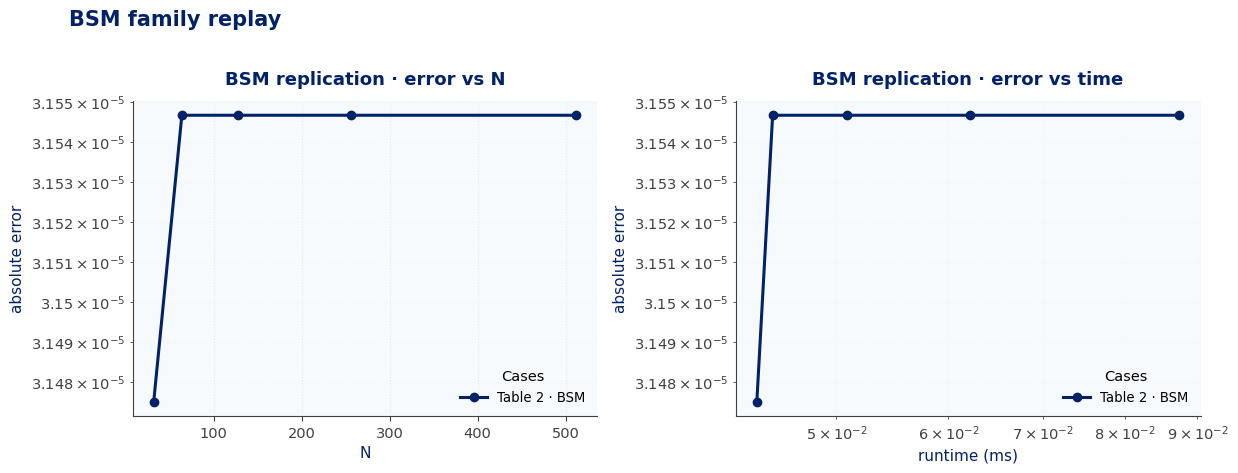

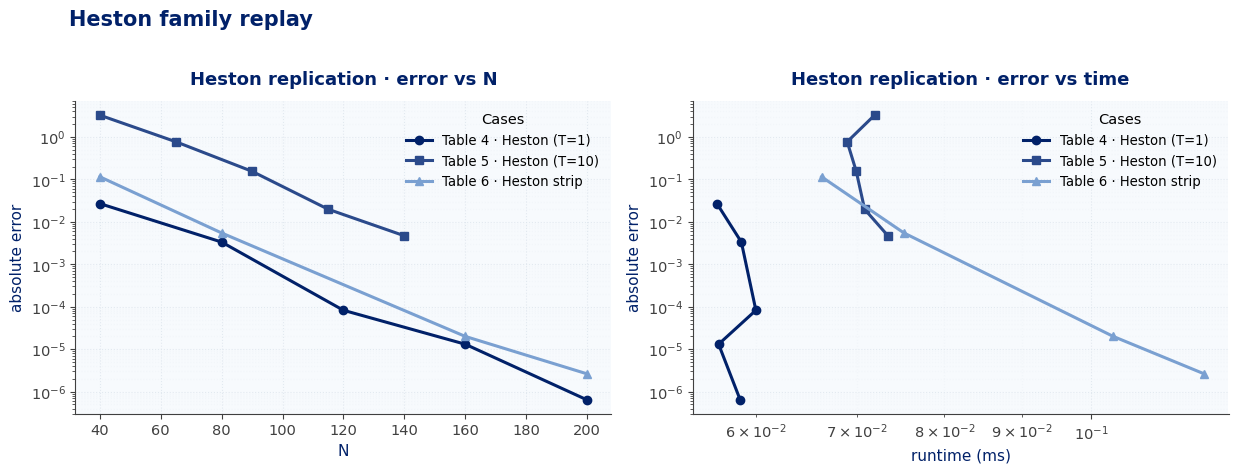

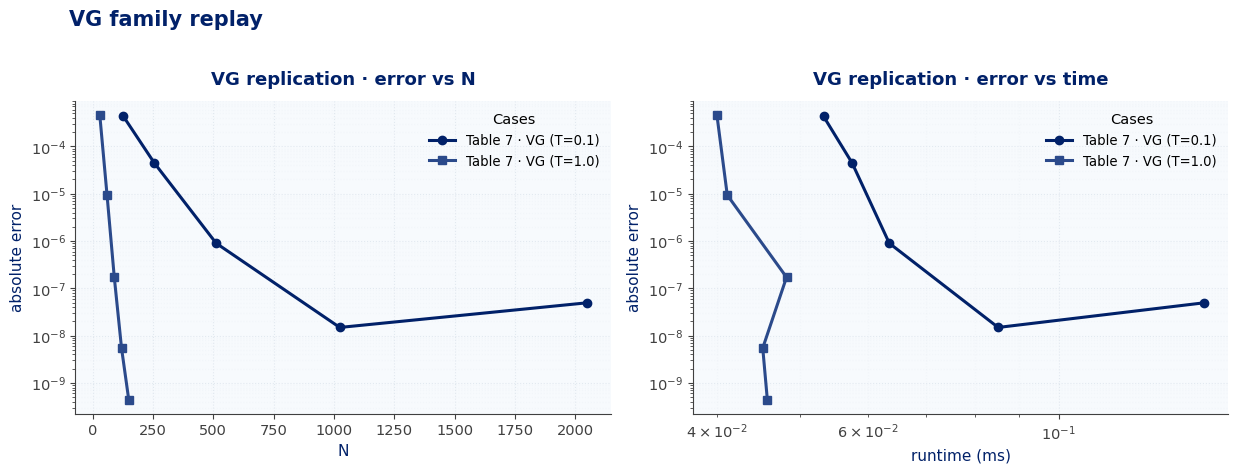

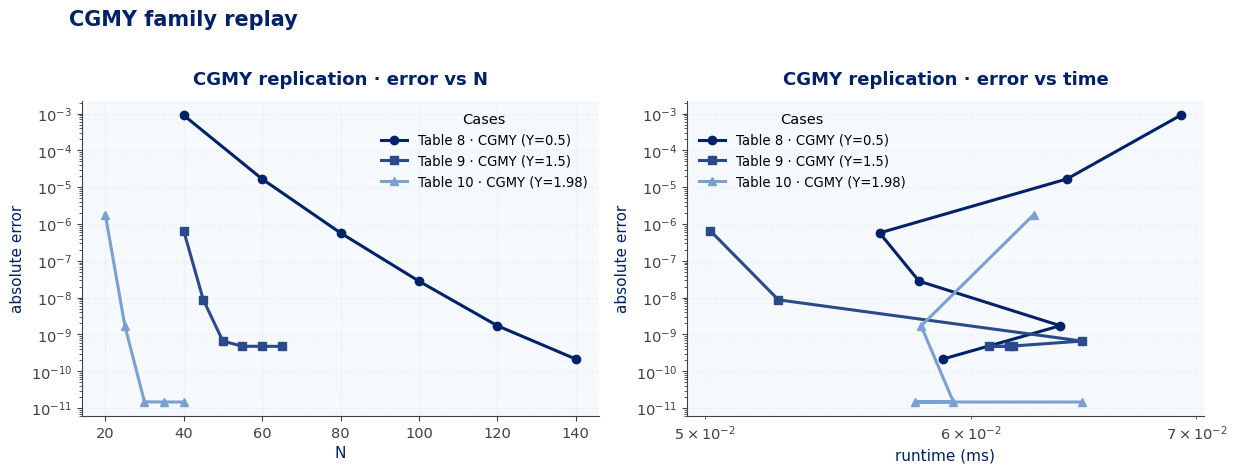

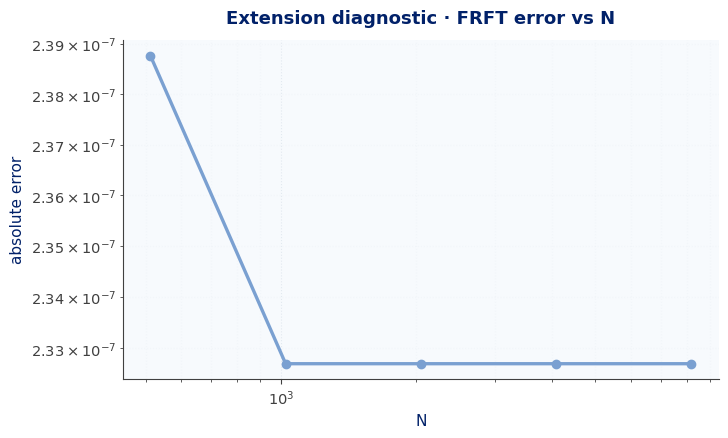

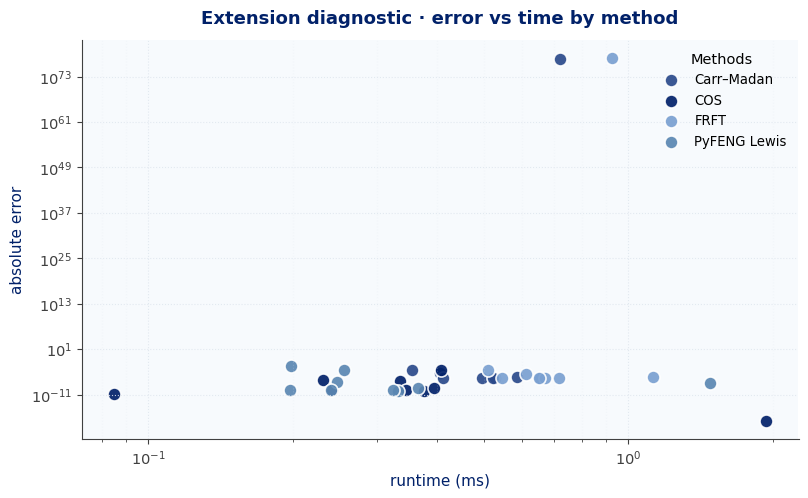

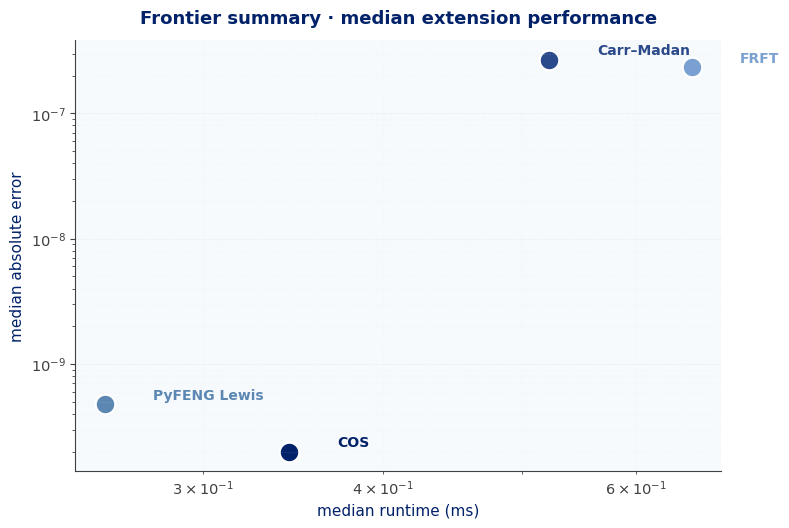

figures saved to /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan/benchmarks/paper_replications/fo2008_cos/outputs/figures


In [17]:
# Cell 18 — Figures: per-family error vs N and error vs time, plus a frontier.

def _collect_replication_long():
    rows = []

    def _push(cid, df):
        for _, r in df.iterrows():
            rows.append({
                'case_id': cid,
                'N': int(r['N']),
                'our_err': float(r['our err']) if 'our err' in r else float(r['our COS err']),
                'our_ms': float(r['our ms']) if 'our ms' in r else float(r['our COS ms']),
            })

    for _, r in BSM_DF.iterrows():
        rows.append({
            'case_id': 'bsm_table2',
            'N': int(r['N']),
            'our_err': float(r['our COS err']),
            'our_ms': float(r['our COS ms']),
        })

    for cid, df in [
        ('heston_table4_t1', T4_DF),
        ('heston_table5_t10', T5_DF),
        ('heston_table6_strip', T6_DF),
        ('vg_table7_t01', VG_T01_DF),
        ('vg_table7_t1', VG_T1_DF),
        ('cgmy_table8_y05', T8_DF),
        ('cgmy_table9_y15', T9_DF),
        ('cgmy_table10_y198', T10_DF),
    ]:
        _push(cid, df)
    return pd.DataFrame(rows)


LONG = _collect_replication_long()
FAMILY = {
    'BSM': ['bsm_table2'],
    'Heston': ['heston_table4_t1', 'heston_table5_t10', 'heston_table6_strip'],
    'VG': ['vg_table7_t01', 'vg_table7_t1'],
    'CGMY': ['cgmy_table8_y05', 'cgmy_table9_y15', 'cgmy_table10_y198'],
}
family_palette = [CU_BLUE, CU_MID, CU_LIGHT, CU_ORANGE]
markers = ['o', 's', '^', 'D']

for fam, cids in FAMILY.items():
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), facecolor='white')
    for ax in axes:
        ax.set_facecolor(CU_BG)

    for idx, cid in enumerate(cids):
        sub = LONG[LONG.case_id == cid].sort_values('N')
        color = family_palette[idx % len(family_palette)]
        marker = markers[idx % len(markers)]
        label = human_case(cid)
        err = np.asarray(sub['our_err'].clip(lower=1e-18), dtype=float)
        axes[0].plot(sub['N'], err, color=color, linewidth=2.2, marker=marker,
                     markersize=6, label=label)
        axes[1].plot(sub['our_ms'], err, color=color, linewidth=2.2, marker=marker,
                     markersize=6, label=label)

    finish_axes(axes[0], title=f'{fam} replication · error vs N',
                xlabel='N', ylabel='absolute error', yscale='log')
    finish_axes(axes[1], title=f'{fam} replication · error vs time',
                xlabel='runtime (ms)', ylabel='absolute error',
                xscale='log', yscale='log')
    axes[0].legend(title='Cases', loc='best')
    axes[1].legend(title='Cases', loc='best')
    fig.suptitle(f'{fam} family replay', x=0.06, y=1.02, ha='left',
                 fontsize=15, color=CU_BLUE, fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGDIR / f'fig_family_{fam.lower()}.png', dpi=150)
    plt.show()

if 'FRFT_SWEEP_DF' in globals() and not FRFT_SWEEP_DF.empty:
    fig, ax = plt.subplots(figsize=(7.4, 4.5), facecolor='white')
    ax.set_facecolor(CU_BG)
    sub = FRFT_SWEEP_DF.dropna(subset=['N', 'error']).sort_values('N')
    err = np.asarray(sub['error'].clip(lower=1e-18), dtype=float)
    ax.plot(sub['N'], err, color=METHOD_COLORS['frft'], linewidth=2.4,
            marker='o', markersize=6)
    finish_axes(ax, title='Extension diagnostic · FRFT error vs N',
                xlabel='N', ylabel='absolute error', xscale='log', yscale='log')
    fig.tight_layout()
    fig.savefig(FIGDIR / 'fig_extension_error_vs_n.png', dpi=150)
    plt.show()

frontier_case = (
    EXT_DF.groupby(['case_id', 'method'], as_index=False)
          .agg(error=('error', 'mean'), time_ms=('time_ms', 'mean'))
)
frontier_method = (
    frontier_case.groupby('method', as_index=False)
                 .agg(error=('error', 'median'), time_ms=('time_ms', 'median'))
)

fig, ax = plt.subplots(figsize=(8.2, 5.1), facecolor='white')
ax.set_facecolor(CU_BG)
for meth, sub in frontier_case.groupby('method'):
    ax.scatter(sub['time_ms'], sub['error'].clip(lower=1e-18), s=88,
               color=METHOD_COLORS.get(meth, CU_MID), edgecolor='white',
               linewidth=1.2, alpha=0.92, label=human_method(meth))
finish_axes(ax, title='Extension diagnostic · error vs time by method',
            xlabel='runtime (ms)', ylabel='absolute error',
            xscale='log', yscale='log')
ax.legend(title='Methods', loc='best')
fig.tight_layout()
fig.savefig(FIGDIR / 'fig_extension_error_vs_time.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 5.4), facecolor='white')
ax.set_facecolor(CU_BG)
for _, row in frontier_method.sort_values('time_ms').iterrows():
    color = METHOD_COLORS.get(row['method'], CU_MID)
    x = float(row['time_ms'])
    y = max(float(row['error']), 1e-18)
    ax.scatter(x, y, s=200, color=color, edgecolor='white', linewidth=1.6)
    ax.text(x * 1.08, y * 1.10, human_method(row['method']), color=color,
            fontsize=10, fontweight='semibold')
finish_axes(ax, title='Frontier summary · median extension performance',
            xlabel='median runtime (ms)', ylabel='median absolute error',
            xscale='log', yscale='log')
fig.tight_layout()
fig.savefig(FIGDIR / 'fig_frontier.png', dpi=150)
plt.show()
print('figures saved to', FIGDIR)

<!-- fo2008-report-section -->
## Final conclusion and markdown summary

<div class="cu-card cu-soft">
  <p>The final cell writes a short <code>SUMMARY.md</code> that mirrors the notebook at a higher level: what replicated cleanly, what is only a local reproduction, and where the comparison needs caution.</p>
</div>

In [18]:
# Cell 19 — Conclusions & write SUMMARY.md.

def _fmt_band(df, err_col='our err', paper_col='paper err'):
    ours = df[err_col].astype(float)
    if paper_col in df:
        papers = df[paper_col].astype(float)
        return f'ours [{ours.min():.2e}, {ours.max():.2e}] vs paper [{papers.min():.2e}, {papers.max():.2e}]'
    return f'ours [{ours.min():.2e}, {ours.max():.2e}]'

lines = [
    '# FO2008 replication — summary', '',
    'Generated by `notebooks/fo2008_replication.ipynb`.', '',
    'Replication policy: paper N-grids, our own CPU timings (median of 10 reps), ',
    'error measured against the reference value listed in the paper summary note.', '',
    '## What actually went wrong in the bad-looking rows', '',
    '- **The replication is not one single failure mode.** COS is being tested with the paper N-grids, ',
    '  local characteristic functions, local cumulants, our own hardware timings, and the registry reference values.',
    '- **BSM Table 2 is reference-limited.** The registry stores the printed four-decimal prices from the paper, ',
    '  so our measured COS error floors around 3e-5 even when the method itself has converged beyond that. ',
    '  The paper\'s 1e-15 line was almost certainly computed against full-precision Black-Scholes values.',
    '- **Heston Table 5 is a long-maturity resolution stress test.** T=10 with L=32 creates a very wide COS ',
    '  interval; the paper N-grid is not enough for our auto-grid/cumulant implementation to match the published ',
    '  error column. The high-N extension reaches ~1e-10, so the CF/pricer wiring is not broken.',
    '- **Heston Table 6 is a self-reference convergence check.** FO2008 does not publish all 21 reference prices; ',
    '  this notebook builds an N=1024 COS strip and compares smaller N values to it. That is useful, but it is ',
    '  not an exact reproduction of the paper\'s hidden reference strip.',
    '- **Carr-Madan differences are grid-choice differences, not COS differences.** The exact damping/grid choices ',
    '  for the paper\'s Carr-Madan column are not fully specified; we use eta=0.25 and alpha=1.5.',
    '- **CGMY Y=1.98 is numerically hostile by construction.** We use the paper truncation (-100, 20); the final ',
    '  comparisons are near floating-point/noise scale, so status labels can look worse than the actual price error.',
    '',
    '## How COS was set up', '',
    '- For BSM, Heston, and VG, each run builds the local model CF, computes local cumulants, and calls ',
    '  `cos_auto_grid(cums, N=N, L=paper_L)`.',
    '- `cos_auto_grid` uses the FO truncation rule `a,b = c1 ± L*sqrt(c2 + sqrt(abs(c4)))`.',
    '- `cos_prices` expands the log-return density on `[a,b]` and uses analytic call-payoff coefficients.',
    '- For CGMY Tables 8-10, the notebook bypasses cumulant auto-grids and uses the explicit paper intervals.',
    '',
    '## Tables', '',
    f'- **Table 2 (BSM, COS vs CM)** — COS: {_fmt_band(BSM_DF, "our COS err", "paper COS err")}. ',
    '  This is dominated by rounded printed reference prices, not by a COS convergence failure.',
    f'- **Table 4 (Heston T=1)** — {_fmt_band(T4_DF)}. Error decays with N, but not at the paper\'s exact rate.',
    f'- **Table 5 (Heston T=10, L=32)** — {_fmt_band(T5_DF)}. Long maturity requires more N under our setup.',
    f'- **Table 6 (Heston strip, 21 K)** — {_fmt_band(T6_DF)}. Reference is our own N=1024 COS price ',
    '  (FO2008 does not publish a per-strike reference).',
    f'- **Table 7 (VG T=0.1)** — {_fmt_band(VG_T01_DF)}.',
    f'- **Table 7 (VG T=1.0)** — {_fmt_band(VG_T1_DF)}.',
    f'- **Table 8 (CGMY Y=0.5)** — {_fmt_band(T8_DF)}.',
    f'- **Table 9 (CGMY Y=1.5)** — {_fmt_band(T9_DF)}.',
    f'- **Table 10 (CGMY Y=1.98)** — {_fmt_band(T10_DF)}. Known-hostile; ',
    '  the paper notes an instability near the stability boundary. We use the ',
    '  paper\'s (-100, 20) truncation explicitly rather than the cumulant auto-grid.',
    '', 'Figures are saved under `benchmarks/paper_replications/fo2008_cos/outputs/figures/`.', '', '## Known caveats', '',
    '- **CPU times are not portable.** Paper times are on 2008 hardware; ours are Python/NumPy on this machine. ',
    '  The `paper_time_ms` column is a historical reference only.',
    '- **Printed references are not full-precision references.** Table 2 is the clearest example: rounded printed ',
    '  prices impose a hard error floor.',
    '- **Paper-faithful N/L does not mean paper-identical hidden implementation details.** The notebook reproduces ',
    '  visible grids and parameters; it cannot reproduce hidden reference precision or every internal truncation choice.',
    '', '## Extension summary', '',
    '- The high-N extension shows the in-house COS machinery can converge past the bad-looking paper-grid rows.',
    '- Carr-Madan FFT produces wide-strip pricing cheaply but needs damping/grid tuning and interpolation.',
    '- FRFT is comparable to Carr-Madan at the cost of an extra tuning knob (lam).',
]

with open(OUTDIR / 'SUMMARY.md', 'w') as f:
    f.write('\n'.join(lines))
print('wrote', OUTDIR / 'SUMMARY.md')
print('\n'.join(lines[:35]))


wrote /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan/benchmarks/paper_replications/fo2008_cos/outputs/SUMMARY.md
# FO2008 replication — summary

Generated by `notebooks/fo2008_replication.ipynb`.

Replication policy: paper N-grids, our own CPU timings (median of 10 reps), 
error measured against the reference value listed in the paper summary note.

## What actually went wrong in the bad-looking rows

- **The replication is not one single failure mode.** COS is being tested with the paper N-grids, 
  local characteristic functions, local cumulants, our own hardware timings, and the registry reference values.
- **BSM Table 2 is reference-limited.** The registry stores the printed four-decimal prices from the paper, 
  so our measured COS error floors around 3e-5 even when the method itself has converged beyond that. 
  The paper's 1e-15 line was almost certainly computed against full-precision Black-Scholes values.
- **Heston Table 5 is a long-maturity re